In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py
from torch import nn

downloaded the dataset from the week1 coursera programming assignment named "Convolution_model_Application", by using the code:
```
from IPython.display import FileLinks
FileLinks('datasets/')
```
This code will display the files available in the 'datasets/' directory, allowing you to access and download

In [2]:
with h5py.File("../datasets/hand_signs/train_signs.h5", "r") as f:
    print(f.keys())
    train_classes = np.array(f["list_classes"])
    train_x = np.array(f["train_set_x"])
    train_y = np.array(f["train_set_y"])
    
    

<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>


In [3]:
train_x

array([[[[227, 220, 214],
         [227, 221, 215],
         [227, 222, 215],
         ...,
         [232, 230, 224],
         [231, 229, 222],
         [230, 229, 221]],

        [[227, 221, 214],
         [227, 221, 215],
         [228, 221, 215],
         ...,
         [232, 230, 224],
         [231, 229, 222],
         [231, 229, 221]],

        [[227, 221, 214],
         [227, 221, 214],
         [227, 221, 215],
         ...,
         [232, 230, 224],
         [231, 229, 223],
         [230, 229, 221]],

        ...,

        [[119,  81,  51],
         [124,  85,  55],
         [127,  87,  58],
         ...,
         [210, 211, 211],
         [211, 212, 210],
         [210, 211, 210]],

        [[119,  79,  51],
         [124,  84,  55],
         [126,  85,  56],
         ...,
         [210, 211, 210],
         [210, 211, 210],
         [209, 210, 209]],

        [[119,  81,  51],
         [123,  83,  55],
         [122,  82,  54],
         ...,
         [209, 210, 210],
        

In [4]:
with h5py.File("../datasets/hand_signs/test_signs.h5", "r") as f:
    print(f.keys())
    test_classes = np.array(f["list_classes"])
    test_x = np.array(f["test_set_x"])
    test_y = np.array(f["test_set_y"])

<KeysViewHDF5 ['list_classes', 'test_set_x', 'test_set_y']>


In [5]:
print(f"shape of training set x = {train_x.shape}, y = {train_y.shape}")
print(f"shape of test set x = {test_x.shape}, y = {test_y.shape}")

shape of training set x = (1080, 64, 64, 3), y = (1080,)
shape of test set x = (120, 64, 64, 3), y = (120,)


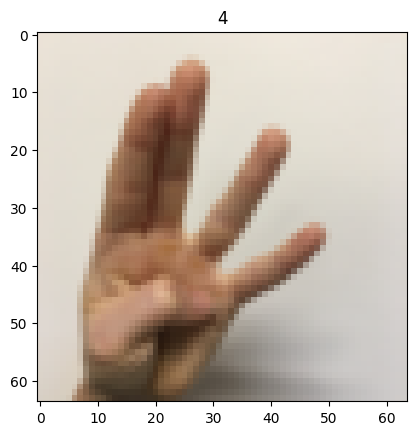

In [6]:
index = 9
plt.imshow(train_x[index])
plt.title(train_y[index])
plt.show()

In [7]:
# normalization
train_x = train_x/255.0 #scales pixel values from [0, 255] → [0, 1]
test_x = test_x/255.0

# flatten the images
    # train_x = train_x.reshape(train_x.shape[0], -1)
    # test_x = test_x.reshape(test_x.shape[0], -1)

print("train_x shape = ",train_x.shape)
print("test_x sape = ", test_x.shape)


train_x shape =  (1080, 64, 64, 3)
test_x sape =  (120, 64, 64, 3)


```
train_x shape =  (1080, 64, 64, 3)
test_x shape =  (120, 64, 64, 3)
this is the problem, pytorch expects (batch_size, channels, height, width) but we have (batch_size, height, width, channels)
```

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
device

'cuda'

In [10]:
train_x = torch.from_numpy(train_x).float().to(device)
train_y = torch.from_numpy(train_y).long().to(device)
test_x = torch.from_numpy(test_x).float().to(device) # long because loss function requires longtensor
test_y = torch.from_numpy(test_y).long().to(device)

In [11]:
train_x = train_x.permute(0, 3, 1, 2)
test_x = test_x.permute(0, 3, 1, 2)

```
After Conv layer:
values = random, messy, unstable

Batch normalization is used to address the issue of unstable and messy values after the convolutional layer. It normalizes the output of the previous layer by adjusting and scaling the activations.
```

In [12]:
class finger_count(nn.Module):
    def __init__(self):        # layer architecture are defined here
        super().__init__()
        
        #conv layer
        self.conv = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 7, stride = 1)
        
        #batch normalization
        self.bn = nn.BatchNorm2d(32) #dynamic normalization at every layer during training and 32 is the expected channel
        
        #pooling
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        
        #flatten
        self.flatten = nn.Flatten()
        
        #fully connected layer
        self.fc = nn.Linear(32*32*32, 10)
        
    def forward(self, x): # here you define the flow of data
        
        #padding
        x = nn.functional.pad(x, (3,3,3,3))
        
        #conv layer
        x = self.conv(x)
        
        #normalize
        x = self.bn(x)
        
        #activation
        x = nn.functional.relu(x)
        
        #pooling
        x = self.pool(x)
        
        #flatten
        x = self.flatten(x)
        
        #fully connected
        x = self.fc(x)
        
        return x
        

In [13]:
def train_model(epochs, lr, train_x, train_y, model, iter_num):
    
    loss = nn.CrossEntropyLoss()
    
    optimizer = torch.optim.Adam(params = model.parameters(), lr = lr)
    
    for epoch in range(epochs):
        model.train()
        
        y_pred_train = model(train_x)
        
        cal_loss = loss(y_pred_train, train_y)
        
        optimizer.zero_grad()
        
        cal_loss.backward()
        
        optimizer.step()
        
        if epoch % (iter_num) == 0:
            print(f"for training iteration {epoch}, loss = {cal_loss.item():.4f}")
          


In [14]:
model0 = finger_count().to(device)
train_model(100, 0.0001,train_x, train_y, model0, 10)

for training iteration 0, loss = 2.7686
for training iteration 10, loss = 1.1368
for training iteration 20, loss = 0.7377
for training iteration 30, loss = 0.5278
for training iteration 40, loss = 0.3964
for training iteration 50, loss = 0.3059
for training iteration 60, loss = 0.2406
for training iteration 70, loss = 0.1921
for training iteration 80, loss = 0.1552
for training iteration 90, loss = 0.1270


In [15]:
model0.eval()
with torch.no_grad():
    outputs = model0(test_x)
    preds = torch.argmax(outputs, dim = 1)
    correct = (preds == test_y).sum().item()
    total = test_y.size(0)

    accuracy = correct / total
    print("Accuracy:", accuracy)
        

Accuracy: 0.9083333333333333


In [ ]:
torch.argmax(outputs, dim = 1)

tensor([0, 0, 0, 5, 1, 0, 3, 1, 5, 1, 5, 1, 3, 1, 1, 3, 5, 4, 0, 4, 5, 4, 2, 5,
        3, 5, 4, 2, 1, 4, 3, 1, 0, 3, 1, 1, 0, 4, 2, 3, 3, 3, 0, 2, 3, 1, 1, 2,
        0, 3, 4, 1, 2, 0, 4, 0, 4, 0, 4, 5, 5, 5, 2, 4, 4, 5, 0, 1, 3, 5, 0, 4,
        3, 2, 3, 4, 3, 5, 1, 5, 2, 0, 1, 3, 2, 4, 2, 1, 4, 5, 5, 0, 0, 4, 5, 5,
        3, 3, 5, 2, 2, 2, 0, 1, 4, 3, 0, 4, 3, 4, 1, 3, 2, 4, 2, 2, 1, 3, 1, 3],
       device='cuda:0')

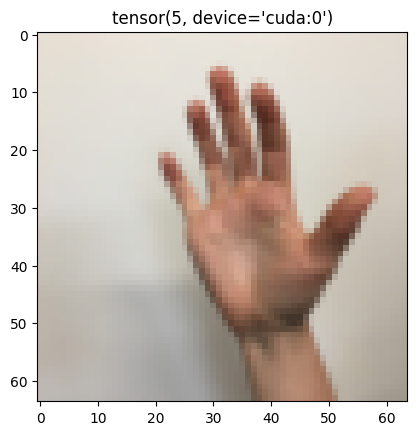

In [25]:
index = 10
plt.imshow(test_x[index].permute(1,2,0).to("cpu"))
plt.title(preds[index])
plt.show()

In [30]:
from torchsummary import summary
summary(model0, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]           4,736
       BatchNorm2d-2           [-1, 32, 64, 64]              64
         MaxPool2d-3           [-1, 32, 32, 32]               0
           Flatten-4                [-1, 32768]               0
            Linear-5                   [-1, 10]         327,690
Total params: 332,490
Trainable params: 332,490
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 2.50
Params size (MB): 1.27
Estimated Total Size (MB): 3.82
----------------------------------------------------------------


In [31]:
torch.save(model0.state_dict(),"../saved_models/hand_signs.pth")